<a href="https://colab.research.google.com/github/jirvingphd/ai-aoe-workshop-backup/blob/main/notebooks_fixed_vers/(AICOE_Workshop_02)_LangChain_Output_Parsers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 2: LangChain Output Parsers

## Introduction

In LangChain, output parsers are essential components that help **interpret and format** the results returned by language models. They allow you to extract structured information from the model's raw output, making it easier to work with in your applications. </br>
**Functionality** - Output parsers take the unstructured text output from a language model and convert it into a structured format, such as JSON, dictionaries, or custom classes.

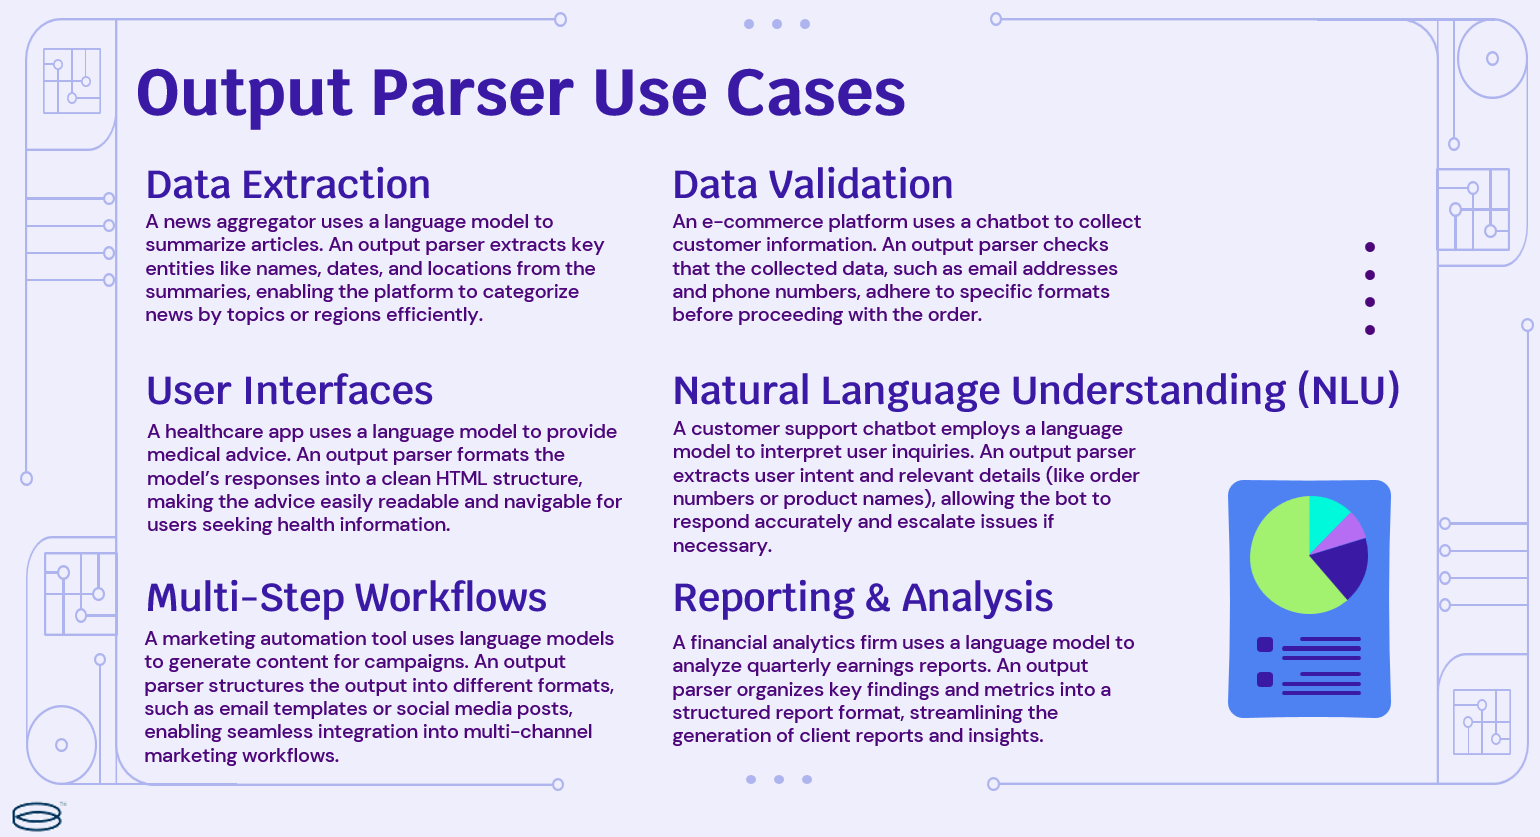

In [ ]:
#Install relevant libraries
# 08/08/25 - exact versions added
!pip install openai==1.98.0
!pip install langchain-openai==0.3.28
!pip install langchain==0.3.27
!pip install langchain-community==0.3.27
!pip install httpx==0.28.1

In [4]:
# Importing relevant libraries

from langchain.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field, validator
from langchain.output_parsers import  ResponseSchema
from langchain.output_parsers import CommaSeparatedListOutputParser, StructuredOutputParser, PandasDataFrameOutputParser
from langchain_core.output_parsers import JsonOutputParser
from langchain.output_parsers import XMLOutputParser
from langchain_openai import ChatOpenAI
from typing import List, Dict, Any, Optional
from getpass import getpass
import openai
import pprint
import pandas as pd
import warnings
import os

warnings.filterwarnings('ignore', category=DeprecationWarning)

In [6]:
#Define an OpenAI API Key
OPENAI_API_KEY = getpass('Enter the OpenAI API key value: ')
print("Successfully assigned an OpenAI API Key!")

# ## UPDATE FROM WORKSHOP 4
# from google.colab import userdata
# import os
# ## API Key from Secrets sidebar
# OPENAI_API_KEY =  userdata.get('OPENAI_API_KEY')

os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY


### Technical Know-How

There are two main methods an output parser must implement:

- **"Get format instructions"**: A method which returns a string containing instructions for how the output of a language model should be formatted. </br>
- **"Parse"**: A method which takes in a string (assumed to be the response from a language model) and parses it into some structure.</br>

And then one optional one:</br>
- **"Parse with prompt"**: A method which takes in a string (assumed to be the response from a language model) and a prompt (assumed to be the prompt that generated such a response) and parses it into some structure. The prompt is largely provided in the event the OutputParser wants to retry or fix the output in some way, and needs information from the prompt to do so.

## Types of Output Parsers

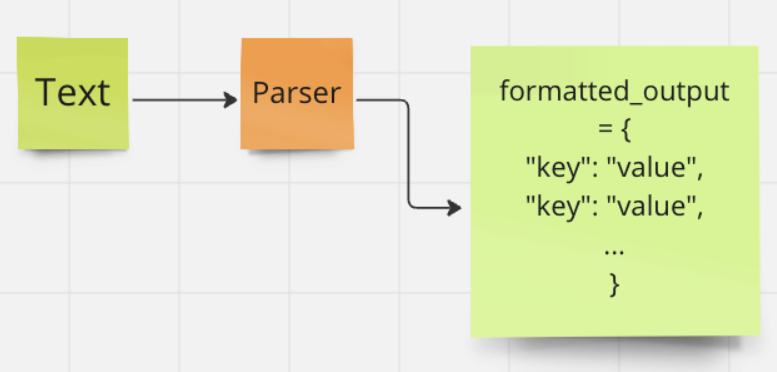

### 1. Pydantic Parser

The Pydantic Parser in LangChain provides a powerful tool for validating and structuring data in accordance with Pydantic models. Pydantic is a data validation library that enforces type checks and ensures data integrity. Here are some key features and functionalities of the Pydantic Parser:</br>
- **Type Enforcement**: The parser ensures that all data conforms to specified types, providing strong guarantees about the nature of the data being processed, which helps prevent runtime errors.</br>

- **Nested Data Structures**: It supports complex data models, allowing for the validation of nested objects and lists, which is ideal for handling hierarchical data representations.</br>

- **Field Customization**: Users can define custom validation logic for individual fields, including regex patterns, value constraints, and more, enabling fine-grained control over data integrity.</br>

- **Automatic Documentation**: The Pydantic models can generate JSON Schema documentation automatically, aiding in understanding data structures and facilitating API development.</br>

- **Efficient Serialization**: The parser provides convenient methods for serializing and deserializing data, making it easy to convert between Python objects and formats like JSON, enhancing data interchange capabilities.</br>

**Example 1**: Extracting Key Entities from a Product Description with the Pydantic Output Parser

In [7]:
# Define the desired data structure for product inquiries.
class ProductInfo(BaseModel):
    product_name: str = Field(description="The name of the product")
    availability: str = Field(description="Availability status of the product")
    price: str = Field(description="Price of the product")

# Define the OpenAI model
llm = ChatOpenAI(
        model="gpt-3.5-turbo",
        openai_api_key=OPENAI_API_KEY,
        temperature=0,
        streaming=True
    )

# Set up a parser + inject instructions into the prompt template.
parser = PydanticOutputParser(pydantic_object=ProductInfo)

prompt_template = """

Provide detailed product information based on the user query.

Format Instructions:
{format_instructions}

Query:
{query}

"""

# Define the prompt detailing instructions to process product information
prompt = PromptTemplate(
    template=prompt_template,
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

# Example user query intended to prompt a language model to populate the data structure.
chain = prompt | llm | parser
user_query = "What is the price and availability of the latest smartwatch?"
output = chain.invoke({"query": user_query})

print(output.json())

{"product_name":"Latest Smartwatch","availability":"In stock","price":"$199.99"}


**Example 2**: Analyzing and Structuring a Company's Quarterly Earnings Report Using the Pydantic Output Parser.

In [8]:
# Define your desired data structure for financial reports.
class EarningsReport(BaseModel):
  company_name: str = Field(description="The name of the company")
  quarter: str = Field(description="The financial quarter of the report")
  revenue: float = Field(description="Total revenue for the quarter")
  profit: float = Field(description="Total profit for the quarter")
  earnings_per_share: float = Field(description="Earnings per share")
  key_highlights: List[str] = Field(default_factory=list, description="Key highlights from the earnings call")

# Set up a parser with the Pydantic model.
parser = PydanticOutputParser(pydantic_object=EarningsReport)

# Prepare a prompt to get structured earnings report information.
prompt = PromptTemplate(
    template="Analyze the following earnings report and provide structured data:\n{format_instructions}\n{query}\n",
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

# Example user query to analyze a company's earnings report.
query = (
    "Analyze the earnings report of TechCorp for Q3 2023. "
    "The report states: 'TechCorp achieved a revenue of $5 million, with a profit of $1.5 million and an earnings per share of $0.75. "
    "Key highlights include a 10% increase in customer subscriptions and expansion into new markets.'"
)

chain = prompt | llm | parser
output = chain.invoke({"query": query})

print(output.json())


{"company_name":"TechCorp","quarter":"Q3 2023","revenue":5000000.0,"profit":1500000.0,"earnings_per_share":0.75,"key_highlights":["10% increase in customer subscriptions","Expansion into new markets"]}


### 2. CSV Parser

Comma-Separated Values (CSV) files are a popular format for storing tabular data in plain text, allowing for easy data exchange and readability by both humans and machines. Each line represents a record, with fields separated by commas or other delimiters. </br>
</br>
The CSV output parser in LangChain is designed to facilitate the extraction and structuring of data from CSV formatted outputs generated by language models. Here are some key features and functionalities:</br>
- **Data Structuring**: The parser automatically converts the raw CSV text output into structured data formats, such as lists or dictionaries, making it easier to manipulate and analyze the data programmatically. </br>
- **Flexible Delimiters**: While CSV typically uses commas to separate fields, the parser can also handle other delimiters, like semicolons or tabs, allowing for versatility in processing different CSV formats. </br>
- **Error Handling**: The parser includes mechanisms to manage common errors in CSV files, such as missing values or incorrect formatting, ensuring robustness in data processing </br>
- **Integration with LangChain**: The CSV output parser can be seamlessly integrated into workflows that involve language models, allowing for smooth transitions from natural language prompts to structured data outputs. </br>
- **Customizable Output**: Users can define how they want the parsed data to be structured, whether as lists of records or as dictionaries with specific keys, enhancing the parser's usability for various applications.

**Example 1**: Automating Resume Data Extraction to CSV Format Using a Comma-Separated List Output Parser.




In [9]:
#Define a CSV output parser
output_parser = CommaSeparatedListOutputParser()

format_instructions = "Provide the extracted details in CSV format: Name, Email, Phone Number, Skills, Work Experience, Education."


prompt = PromptTemplate(
    template="Extract key details from the following resume:\n{resume}\n{format_instructions}",
    input_variables=["resume"],
    partial_variables={"format_instructions": format_instructions},
)

# Define LLM Model using ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Create a chain binding the prompt with the llm model and output parser
chain = prompt | llm | output_parser

#Define the user input
user_input = """John Doe
Email: john.doe@example.com
Phone: (123) 456-7890
Skills: Python, Data Analysis, Project Management
Work Experience: Software Engineer at TechCorp (2019-present), Data Analyst at DataInc (2017-2019)
Education: B.S. in Computer Science, University of Example (2017)"""

#Invoke LLM Chain
output = chain.invoke({"resume": user_input})

# Print the structured CSV output
print(output)

['Name', 'Email', 'Phone Number', 'Skills', 'Work Experience', 'Education', 'John Doe', 'john.doe@example.com', '(123) 456-7890', 'Python', 'Data Analysis', 'Project Management', 'Software Engineer at TechCorp (2019-present)', 'Data Analyst at DataInc (2017-2019)', 'B.S. in Computer Science', 'University of Example (2017)']


**Example 2**: Extracting Key Details from Legal Invoices into CSV Format

In [10]:

# Outline the format instructions on the exact entities to extract
format_instructions = "Provide the extracted details in CSV format: Invoice Number, Client Name, Invoice Date, Due Date, Total Amount, Description of Services."

prompt = PromptTemplate(
    template="Extract key details from the following legal invoice:\n{invoice}\n{format_instructions}",
    input_variables=["invoice"],
    partial_variables={"format_instructions": format_instructions},
)

# Define LLM Model using ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Create a chain binding the prompt with the llm model and output parser
chain = prompt | llm | output_parser

user_input = """The invoice number 12345 is issued to ABC Corp, with an invoice date of October 15, 2024, and a due date of November 15, 2024.
The total amount due is $5000.00, which covers services including legal consultation, document preparation, and court representation."""

output = chain.invoke({"invoice": user_input})

# Print the structured CSV output
print(output)


['12345', 'ABC Corp', 'October 15', '2024', 'November 15', '2024', '$5000.00', 'Legal consultation', 'document preparation', 'court representation']


### 3. JSON Parser

In Langchain, JSON parsers are components that help process and extract information from JSON-formatted data. They enable applications to interact with and manipulate JSON structures, making it easier to integrate external data sources, APIs, or even databases into a Langchain pipeline.

This output parser allows users to specify an arbitrary JSON schema and query LLMs for outputs that conform to that schema. Here are some key features and functionalities:

- **Data Extraction**: They can extract specific fields or values from JSON objects, allowing users to focus on the relevant data for their applications.
- **Validation**: Parsers can validate the structure and data types of JSON data to ensure it conforms to expected formats, which helps in preventing errors during processing.
- **Transformation**: They can transform JSON data into different formats or structures, such as converting nested objects into flat representations, or vice versa.
- **Aggregation**: JSON parsers can aggregate data from multiple JSON responses, making it easier to analyze or visualize combined datasets.

**Example 1**: Automating Customer Support Ticket Creation by Structuring User Queries Using JSON Output Parser

In [11]:
class SupportTicket(BaseModel):
    issue_description: str = Field(description="Description of the customer's issue")
    proposed_solution: str = Field(description="Proposed solution for the issue as next steps the customer can take. Assume you have all the information related to the customer")

support_query = "I can't access my account."

parser = JsonOutputParser(pydantic_object=SupportTicket)

prompt = PromptTemplate(
    template="Customer request: {query}\n{format_instructions}\n",
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

# Define LLM Model using ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Create a chain binding the prompt with the llm model and output parser
chain = prompt | llm | parser

result = chain.invoke({"query": support_query})

print(result)

{'issue_description': "I can't access my account.", 'proposed_solution': 'To resolve this issue, please try resetting your password or contact our customer support for further assistance.'}


**Example 2**: Automating Loan Application Processing with Structured Output Generation Using JSON Parser.

In [12]:
class LoanApplication(BaseModel):
    applicant_name: str = Field(description="Name of the loan applicant")
    loan_amount: float = Field(description="Requested loan amount")
    application_status: str = Field(description="Current status of the application")
    recommended_action: str = Field(description="Suggested next steps for processing the application")

loan_application_query = "John Doe has applied for a loan of $10,000 for home improvement. The application is pending review."

parser = JsonOutputParser(pydantic_object=LoanApplication)

prompt = PromptTemplate(
    template="Loan Application Details: {query}\n{format_instructions}\n",
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

# Define LLM Model using ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Create a chain binding the prompt with the llm model and output parser
chain = prompt | llm | parser

result = chain.invoke({"query": loan_application_query})

# Print the structured output
print(result)

{'applicant_name': 'John Doe', 'loan_amount': 10000, 'application_status': 'Pending Review', 'recommended_action': 'Await further communication from the lender'}


### 4. Pandas DF Parser

A Pandas DataFrame is a popular data structure in the Python programming language, commonly used for data manipulation and analysis. It provides a comprehensive set of tools for working with structured data, making it a versatile option for tasks such as data cleaning, transformation, and analysis.

This output parser allows users to specify an arbitrary Pandas DataFrame and query LLMs for data in the form of a formatted dictionary that extracts data from the corresponding DataFrame. Here are several impactful business use cases where a Pandas DataFrame (DF) parser can be utilized:

- **Sales Data Analysis**: Automate the extraction and analysis of sales data from multiple CSV files to generate insights on sales performance, trends, and forecasts. This can help businesses identify top-selling products and seasonal fluctuations.
- **Customer Feedback Aggregation**: Consolidate customer feedback from surveys and reviews into a DataFrame to perform sentiment analysis. Businesses can use this data to improve products and services based on customer sentiment.
- **Financial Reporting**: Extract financial metrics from various spreadsheets into a Pandas DataFrame for quarterly or annual reporting. This can streamline the process of generating financial statements, allowing for quicker decision-making.
- **Inventory Management**: Use a DataFrame parser to consolidate inventory data from different sources (e.g., warehouses, retail locations) to track stock levels, optimize reordering processes, and minimize holding costs.
- **Marketing Campaign Performance**: Analyze marketing campaign data by importing data from multiple sources (e.g., Google Ads, social media platforms) into a DataFrame. This can help assess ROI and inform future marketing strategies.

**Example 1**: Querying Construction Project Data Using Pandas DF Parser

In [13]:
# Solely for documentation purposes.
def format_parser_output(parser_output: Dict[str, Any]) -> None:
    for key, value in parser_output.items():
        if hasattr(value, 'to_dict'):
            parser_output[key] = value.to_dict()
        else:
            parser_output[key] = value  # Keep it as is if it's a scalar
    return pprint.PrettyPrinter(width=4, compact=True).pprint(parser_output)

# Define LLM Model using ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Define your desired Pandas DataFrame for construction projects.
df = pd.DataFrame(
    {
        "project_id": [101, 102, 103, 104],
        "project_name": ["Bridge Construction", "Skyscraper", "Residential Complex", "Highway Expansion"],
        "duration_months": [12, 24, 18, 15],
        "budget_millions": [2.5, 150, 30, 25],
        "num_workers": [50, 200, 75, 100],
    }
)

# Set up a parser and inject instructions into the prompt template.
parser = PandasDataFrameOutputParser(dataframe=df)

# Here's an example of a column operation being performed.
df_query = "Retrieve the budget_millions column."

# Set up the prompt.
prompt = PromptTemplate(
    template="Answer the user query.\n{format_instructions}\n{query}\n",
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

chain = prompt | llm | parser
parser_output = chain.invoke({"query": df_query})

format_parser_output(parser_output)

{'budget_millions': {0: 2.5,
                     1: 150.0,
                     2: 30.0,
                     3: 25.0}}


In [14]:
# Here's an example of a row operation being performed.
df_query = "Retrieve the first row."

parser_output = chain.invoke({"query": df_query})

format_parser_output(parser_output)

{'0': {'budget_millions': 2.5,
       'duration_months': 12,
       'num_workers': 50,
       'project_id': 101,
       'project_name': 'Bridge '
                       'Construction'}}


In [15]:
# Here's an example of a random Pandas DataFrame operation limiting the number of rows
df_query = "Retrieve the average of the duration_months column from rows 1 to 3."

parser_output = chain.invoke({"query": df_query})

format_parser_output(parser_output)

{'mean': np.float64(19.0)}


### 5. Structured Output Parser

The Structured Output Parser in LangChain is a powerful tool for organizing natural language outputs from language models into structured formats, such as dictionaries or JSON. It is optimized for scenarios that involve smaller or less complex models, particularly where the fields can be effectively represented as strings. Here’s a detailed breakdown of its key features and capabilities:

**Basic Structuring**: Converts unstructured text responses into structured data formats like dictionaries or JSON. It is specifically designed for scenarios where fields are simple strings, making the parser lightweight, efficient, and easy to integrate with various applications that require structured outputs.

**Schema Customization**: Users can define custom schemas with specific fields to standardize the structure of outputs. This flexibility ensures consistency and accuracy across outputs, reducing ambiguity and improving the reliability of the data produced by the language model.

**Error Handling**: Equipped with built-in error management features, the parser can handle common issues like missing fields, incorrect data types, or poor formatting. This allows for smoother integration and minimizes the need for manual intervention when parsing responses.

**Optimized for Small LLMs**: The parser is designed with efficiency in mind, making it ideal for smaller language models where simplicity and speed are priorities. By focusing on string-based fields, it reduces the computational overhead, making it suitable for lightweight applications or systems with limited resources.

**Ease of Integration**: The Structured Output Parser is designed to seamlessly integrate into existing systems. Its lightweight nature allows for quick setup and compatibility with multiple APIs or back-end services, reducing development time and effort.


**Example 1:** Automating Athlete Medal Information Retrieval Using a Structured Output Parser

In [16]:
# Define response schemas using ResponseSchema
response_schemas = [
    ResponseSchema(name="athlete_name", description="Name of the athlete"),
    ResponseSchema(name="total_medals", description="Total number of Olympic medals won by the athlete"),
    ResponseSchema(name="events_won", description="Details of the events in which the athlete won medals (e.g., 100m sprint, 200m sprint)"),
    ResponseSchema(name="years_active", description="Years when the athlete competed in the Olympics"),
    ResponseSchema(name="notable_achievements", description="Any other notable achievements or records of the athlete")
]

# Create the StructuredOutputParser using the response schemas
output_parser = StructuredOutputParser(response_schemas=response_schemas)

# Get format instructions from the parser
format_instructions = output_parser.get_format_instructions()

# Define the prompt template
prompt = PromptTemplate(
    template="Provide Olympic information for the athlete {athlete_name}.\n{format_instructions}\n",
    input_variables=["athlete_name"],
    partial_variables={"format_instructions": format_instructions},
)

# Define LLM Model using the updated ChatOpenAI from langchain_openai
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)
# Combine the prompt, LLM, and output parser
athlete_info_chain = prompt | llm | output_parser

# Example user input: Asking about Usain Bolt
athlete_input = "Usain Bolt"

# Invoke the chain to get information about the athlete
output = athlete_info_chain.invoke({"athlete_name": athlete_input})

# Print the structured output
print(output)


{'athlete_name': 'Usain Bolt', 'total_medals': '8', 'events_won': '100m, 200m, 4x100m relay', 'years_active': '2004-2016', 'notable_achievements': 'Usain Bolt is widely regarded as the greatest sprinter of all time. He holds the world records for the 100m (9.58 seconds) and 200m (19.19 seconds) events. Bolt is the only sprinter to win the Olympic 100m and 200m titles at three consecutive Olympics (2008, 2012, 2016).'}


**Example 2:** Automating Comprehensive Room Availability and Booking Information Using a Structured Output Parser

In [17]:
# Define the schema for the structured output
class RoomAvailabilitySchema(BaseModel):
    room_status: str
    next_available_date: Optional[str] = None
    price_per_night: Optional[float] = None
    special_requirements: Optional[str] = None
    booking_policy: Optional[str] = None

# Define the structured output parser using response_schemas with type annotations
class RoomAvailabilityOutputParser(StructuredOutputParser):
    response_schemas: Dict[str, str] = {
        "room_status": "The availability status of the room (Available/Not available)",
        "next_available_date": "The next available date if the room is not currently available",
        "price_per_night": "The price per night for the room, if available",
        "special_requirements": "Any special requirements or conditions for booking this room",
        "booking_policy": "The booking policy for the room, if applicable"
    }

    def parse(self, response: str) -> dict:
        # Parse room status
        if "available" in response.lower():
            room_status = "Available"
        elif "not available" in response.lower():
            room_status = "Not available"
        else:
            room_status = "Unknown"

        # Parse next available date
        next_available_date = None
        if "available from" in response.lower():
            next_available_date = "October 25th"

        # Parse price per night
        price_per_night = None
        if "$" in response:
            price_per_night = 250.0  # Assuming we extract this from the response

        # Parse special requirements
        special_requirements = None
        if "special requirements" in response.lower():
            special_requirements = "No pets allowed, ID required at check-in"

        # Parse booking policy
        booking_policy = None
        if "non-refundable" in response.lower():
            booking_policy = "Non-refundable"
        elif "refundable" in response.lower():
            booking_policy = "Refundable up to 48 hours before check-in"

        return {
            "room_status": room_status,
            "next_available_date": next_available_date,
            "price_per_night": price_per_night,
            "special_requirements": special_requirements,
            "booking_policy": booking_policy
        }

# Instantiate the custom output parser
output_parser = RoomAvailabilityOutputParser()

# Define format instructions
format_instructions = (
    "Provide the room status, next available date if not available, price per night if available, "
    "any special requirements, and the booking policy."
)

# Define the prompt template
prompt = PromptTemplate(
    template=(
        "What is the availability and booking information for the {room_type}? "
        "{format_instructions}"
    ),
    input_variables=["room_type"],
    partial_variables={"format_instructions": format_instructions},
)

# Define LLM Model using the updated ChatOpenAI from langchain_openai
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Using the new chaining syntax
availability_chain = prompt | llm | output_parser

# Example user input: Asking about "Executive Suite"
user_input = "Executive Suite"

# Invoke the chain to get room availability
output = availability_chain.invoke({"room_type": user_input})

print(output)


{'room_status': 'Available', 'next_available_date': None, 'price_per_night': 250.0, 'special_requirements': 'No pets allowed, ID required at check-in', 'booking_policy': None}


### 6. XML Parser

The XML Parser in LangChain is a specialized tool designed to convert and interpret natural language outputs from language models into structured XML formats. It’s ideal for scenarios where XML is the preferred data exchange or storage format, providing robust and organized output management for language models. Here’s an overview of its features and capabilities:

**XML-Based Structuring**: Converts natural language outputs into structured XML data, ensuring that the output is neatly formatted for systems or applications that use XML as their primary data standard. This is useful for environments where XML is commonly used for data interchange, such as web services or document storage systems.

**Schema Flexibility**: Allows users to define custom XML schemas, giving flexibility in structuring the output according to specific application requirements. This ensures that the XML output is consistent, adheres to defined standards, and integrates seamlessly with existing XML-based systems.

**Error Management**: The parser includes sophisticated error handling mechanisms to manage common issues such as missing tags, incorrect data types, or malformed XML structures. It automatically corrects minor errors and flags major discrepancies, ensuring that the output remains valid and usable.

**Compatibility with Complex Data Structures:** Unlike simpler parsers limited to string fields, the XML Parser supports nested elements and attributes, allowing for the representation of more complex data relationships. This makes it suitable for use cases that require hierarchical or multi-level structuring, such as representing configurations, documents, or data exchanges with intricate formats.

**Integration with Existing XML Systems:** The parser is built to seamlessly integrate with XML-based systems, including XML databases, web services, and APIs. It ensures that outputs from language models are compatible with these systems, reducing the need for additional conversion or processing steps.

**Scalable and Adaptable Output Generation:** Capable of handling both simple and complex XML structures, the parser is suitable for applications ranging from small-scale projects to larger enterprise-level integrations. It adapts easily to different schema requirements, ensuring that outputs remain consistent regardless of the complexity or scale of the XML being used.

**Example 1:** Employee Performance Review Summary Using XML Output Parser

In [18]:
# Define response schemas using ResponseSchema
response_schemas = [
    ResponseSchema(name="employee_name", description="Name of the employee being reviewed"),
    ResponseSchema(name="performance_rating", description="Performance rating (e.g., Excellent, Good, Needs Improvement)"),
    ResponseSchema(name="strengths", description="Key strengths demonstrated by the employee"),
    ResponseSchema(name="areas_for_improvement", description="Areas where the employee can improve"),
    ResponseSchema(name="recommended_actions", description="Recommended actions for the employee's development")
]

# Create the XMLOutputParser using the response schemas
output_parser = XMLOutputParser(response_schemas=response_schemas)

# Get format instructions from the parser
format_instructions = output_parser.get_format_instructions()

# Define the prompt template
prompt = PromptTemplate(
    template="Provide the performance review summary for the employee {employee_name} in XML format.\n{format_instructions}\n",
    input_variables=["employee_name"],
    partial_variables={"format_instructions": format_instructions},
)

# Define LLM Model using the updated ChatOpenAI from langchain_openai
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Combine the prompt, LLM, and output parser
employee_review_chain = prompt | llm | output_parser

# Example user input: Asking about an employee named "Alice Johnson"
employee_input = "Alice Johnson"

# Invoke the chain to get the employee performance review in XML format
output = employee_review_chain.invoke({"employee_name": employee_input})

# Print the structured output
print(output)


{'EmployeePerformanceReview': [{'EmployeeName': 'Alice Johnson'}, {'ReviewDate': '2021-10-15'}, {'PerformanceRating': 'Exceeds Expectations'}, {'Feedback': "Alice has consistently exceeded expectations in her role. She has shown great initiative and leadership skills, taking on additional responsibilities and completing tasks efficiently. Her positive attitude and willingness to help others make her a valuable team member. Overall, Alice's performance has been outstanding."}]}


**Example 2**: Shipment Tracking System Using XML Output Parser

In [19]:
# Define response schemas using ResponseSchema
response_schemas = [
    ResponseSchema(name="shipment_id", description="The unique ID of the shipment"),
    ResponseSchema(name="origin", description="Details of the shipment origin, including location and date"),
    ResponseSchema(name="destination", description="Details of the shipment destination, including location and estimated arrival date"),
    ResponseSchema(name="items", description="A list of items in the shipment, including item name, quantity, and handling instructions"),
    ResponseSchema(name="customs_clearance", description="Customs clearance details, including required documents and status"),
    ResponseSchema(name="shipping_status", description="Current status of the shipment (e.g., In Transit, Delayed, Delivered)"),
    ResponseSchema(name="tracking_updates", description="Tracking updates with timestamps and locations")
]

# Create the XMLOutputParser using the response schemas
output_parser = XMLOutputParser(response_schemas=response_schemas)

# Get format instructions from the parser
format_instructions = output_parser.get_format_instructions()

# Define the prompt template
prompt = PromptTemplate(
    template=(
        "Provide detailed XML information about the shipment with ID '{shipment_id}'. "
        "Include origin details, destination, items (with their quantities and handling instructions), customs clearance status, "
        "shipping status, and tracking updates.\n"
        "{format_instructions}\n"
    ),
    input_variables=["shipment_id"],
    partial_variables={"format_instructions": format_instructions},
)

# Define LLM Model using ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", openai_api_key=OPENAI_API_KEY, temperature=0)

# Combine the prompt, LLM, and output parser
shipment_tracking_chain = prompt | llm | output_parser

# Example user input: Asking about a shipment with ID "SH12345"
shipment_input = "SH12345"

# Invoke the chain to get the shipment tracking details in XML format
output = shipment_tracking_chain.invoke({"shipment_id": shipment_input})

# Print the structured output
print(output)


{'shipment': [{'shipmentID': 'SH12345'}, {'origin': [{'country': 'USA'}, {'city': 'New York'}, {'postalCode': '10001'}]}, {'destination': [{'country': 'Germany'}, {'city': 'Berlin'}, {'postalCode': '10115'}]}, {'items': [{'item': [{'name': 'Laptop'}, {'quantity': '2'}, {'handlingInstructions': 'Fragile'}]}, {'item': [{'name': 'Smartphone'}, {'quantity': '3'}, {'handlingInstructions': 'Handle with care'}]}]}, {'customsClearanceStatus': 'Pending'}, {'shippingStatus': 'In transit'}, {'trackingUpdates': [{'update': [{'timestamp': '2022-01-15 10:30:00'}, {'location': 'New York'}, {'status': 'Departed origin'}]}, {'update': [{'timestamp': '2022-01-16 08:45:00'}, {'location': 'Frankfurt'}, {'status': 'Arrived at destination'}]}]}]}


## **Comparison Across All Parsers**

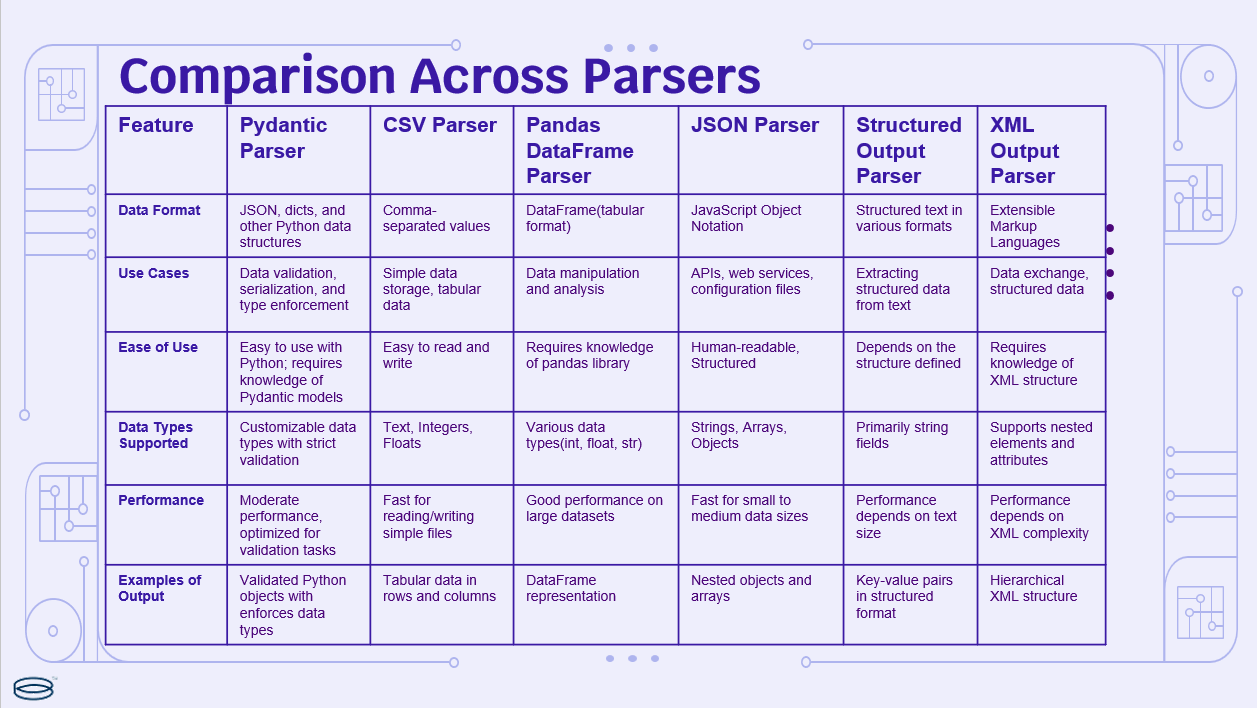

## Reference Resources
- https://python.langchain.com/docs/concepts/output_parsers/
- https://medium.com/@garysvenson09/how-to-extract-information-from-csv-files-using-langchain-a3a8792a7082
- https://cobusgreyling.medium.com/langchain-structured-output-parser-using-openai-c3fe6927beb7
